### Load Data

In [3]:
import pandas as pd
from pymatgen.core import Composition


df = pd.read_csv("data/train_no_ads.csv")
df = df.drop(columns=['sid', 'bulk_id', 'miller_index', 'traj_id', 'slab_sid', 'ads_symbols', 'nads'])

# convert composition str to pymatgen Composition object
pd.options.mode.copy_on_write = True
df['composition'] = df['bulk_symbols'].apply(lambda x: Composition(x))

# remove samples with y <= -800 eV
high_y_mask = df['y_relaxed'] >= -800
df = df[high_y_mask]

print(df['y_relaxed'].describe())

count    12749.000000
mean      -479.220318
std        169.031478
min       -799.881409
25%       -615.805648
50%       -478.374776
75%       -349.990675
max        -56.454107
Name: y_relaxed, dtype: float64


### Fetch Structure

In [ ]:
from mp_api.client import MPRester
import os

key = os.getenv("API_KEY")

def get_structure_from_composition(composition, api_key):
    """Fetch structure from Materials Project given a composition"""
    try:
        with MPRester(api_key=api_key) as mpr:
            # Search for materials with this composition
            docs = mpr.materials.summary.search(
                formula=composition.reduced_formula,
                fields=[
                    "material_id", 
                    "structure", 
                    "energy_above_hull",
                ]
            )
            
            if docs:
                # Sort by energy_above_hull and get the most stable structure
                docs_sorted = sorted(docs, key=lambda x: x.energy_above_hull)
                return docs_sorted[0].structure
            else:
                return None
    except Exception as e:
        print(f"Error fetching structure for {composition}: {e}")
        return None

# Apply to your dataframe
if key:
    df['structure'] = df['composition'].apply(
        lambda comp: get_structure_from_composition(comp, key)
    )
    print(f"Fetched structures for {h['structure'].notna().sum()} compositions")
    
    # drop rows with empty structures
    df = df.dropna(subset='structure').reset_index(drop=True)

### Fetch Materials Project Features

In [3]:
from mp_api.client import MPRester
import os
import time

# Load API key
key = os.getenv("API_KEY")

def get_mp_data(composition, api_key, max_retries=3):
    """
    Fetch multiple properties from Materials Project given a composition.
    Includes retry logic for rate limiting.
    """
    for attempt in range(max_retries):
        try:
            with MPRester(api_key=api_key) as mpr:
                docs = mpr.materials.summary.search(
                    formula=composition.reduced_formula,
                    fields=[
                        "material_id",
                        "structure",
                        "formula_pretty",
                        "symmetry",
                        "volume",
                        "density",
                        "density_atomic",
                        "energy_per_atom",
                        "formation_energy_per_atom",
                        "energy_above_hull",
                        "band_gap",
                        "is_stable",
                        "is_metal",
                        "efermi",
                        "total_magnetization",
                        "num_magnetic_sites",
                        "nsites",
                        "nelements",
                        "elements",
                        "nsites",
                        "composition",
                        "composition_reduced",
                        "theoretical",
                        "database_IDs",
                    ]
                )
                
                if docs:
                    # Sort by energy_above_hull to get most stable structure
                    docs_sorted = sorted(docs, key=lambda x: x.energy_above_hull)
                    most_stable = docs_sorted[0]
                    
                    # Extract symmetry info if available
                    spacegroup_num = None
                    crystal_system = None
                    if hasattr(most_stable, 'symmetry') and most_stable.symmetry:
                        spacegroup_num = most_stable.symmetry.number if hasattr(most_stable.symmetry, 'number') else None
                        crystal_system = most_stable.symmetry.crystal_system if hasattr(most_stable.symmetry, 'crystal_system') else None
                    
                    # Return a dictionary with all the properties
                    return {
                        'mp_material_id': most_stable.material_id,
                        'mp_volume': most_stable.volume,
                        'mp_density': most_stable.density,
                        # 'mp_density_atomic': most_stable.density_atomic,
                        'mp_energy_per_atom': most_stable.energy_per_atom,
                        'mp_formation_energy_per_atom': most_stable.formation_energy_per_atom,
                        'mp_band_gap': most_stable.band_gap,
                        'mp_efermi': most_stable.efermi if hasattr(most_stable, 'efermi') else None,
                        # 'mp_nelements': most_stable.nelements if hasattr(most_stable, 'nelements') else None,
                        # 'mp_nsites': most_stable.nsites if hasattr(most_stable, 'nsites') else None,
                        # 'mp_theoretical': most_stable.theoretical if hasattr(most_stable, 'theoretical') else None,
                        'mp_spacegroup_number': spacegroup_num,
                        # 'mp_crystal_system': crystal_system,
                    }
                else:
                    print(f"No results found for {composition.reduced_formula}")
                    return {}
                    
        except Exception as e:
            error_msg = str(e).lower()
            if 'rate limit' in error_msg or '429' in error_msg:
                wait_time = (attempt + 1) * 2  # Exponential backoff: 2s, 4s, 6s
                print(f"Rate limited for {composition.reduced_formula}. Waiting {wait_time}s... (attempt {attempt+1}/{max_retries})")
                time.sleep(wait_time)
            else:
                print(f"Error fetching data for {composition.reduced_formula}: {e}")
                return None
    
    print(f"Failed to fetch data for {composition.reduced_formula} after {max_retries} attempts")
    return None

def fetch_mp_features(df, composition_col='composition', api_key=None, sleep_time=0.5):
    if api_key is None:
        api_key = os.getenv("API_KEY")
    
    if not api_key:
        print("Error: No API key found. Set API_KEY environment variable.")
        return df
    
    print(f"Fetching Materials Project data for {len(df)} compositions...")
    print(f"This may take a while (~{len(df) * sleep_time / 60:.1f} minutes with rate limiting)")
    
    # Get all MP data as a list of dictionaries
    mp_data_list = []
    
    for idx, comp in enumerate(df[composition_col]):
        if idx % 10 == 0:
            print(f"Processing {idx}/{len(df)}...")
        
        mp_data = get_mp_data(comp, api_key)
        mp_data_list.append(mp_data)
        
        # Sleep to avoid rate limiting
        if sleep_time > 0 and idx < len(df) - 1:
            time.sleep(sleep_time)
    
    # Convert list of dicts to DataFrame
    mp_df = pd.DataFrame(mp_data_list, index=df.index)
    
    # Report success rate
    success_count = mp_df['mp_material_id'].notna().sum()
    print(f"\nSuccessfully fetched data for {success_count}/{len(df)} compositions ({success_count/len(df)*100:.1f}%)")
    
    # Concatenate with original dataframe (aligned by index)
    df_with_mp = pd.concat([df, mp_df], axis=1)
    
    # Print summary of numeric features
    numeric_cols = [col for col in mp_df.columns if mp_df[col].dtype in ['float64', 'int64', 'bool']]
    print(f"\nNumeric MP features added: {len(numeric_cols)}")
    print(f"Columns: {numeric_cols}")
    
    return df_with_mp

h_with_mp = fetch_mp_features(h, composition_col='composition', sleep_time=0.5)
    
# Check for missing data
print("\nMissing data summary:")
mp_cols = [col for col in h_with_mp.columns if col.startswith('mp_')]
print(h_with_mp[mp_cols].isnull().sum())

Fetching Materials Project data for 1387 compositions...
This may take a while (~11.6 minutes with rate limiting)
Processing 0/1387...


Retrieving SummaryDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/12 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/5 [00:00<?, ?it/s]

...

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]


Successfully fetched data for 1387/1387 compositions (100.0%)

Numeric MP features added: 7
Columns: ['mp_volume', 'mp_density', 'mp_energy_per_atom', 'mp_formation_energy_per_atom', 'mp_band_gap', 'mp_efermi', 'mp_spacegroup_number']

Missing data summary:
mp_material_id                  0
mp_volume                       0
mp_density                      0
mp_energy_per_atom              0
mp_formation_energy_per_atom    0
mp_band_gap                     0
mp_efermi                       0
mp_spacegroup_number            0
dtype: int64


### Matminer Featurization

In [4]:
h_featurized = h_with_mp.copy()

from matminer.featurizers.conversions import CompositionToOxidComposition

h_featurized = CompositionToOxidComposition().featurize_dataframe(h_featurized, col_id='composition', ignore_errors=True)

from matminer.featurizers.composition import ElementProperty

magpie_features = [
    "NUnfilled",
    # "MeltingT",
    "ElectronAffinity",
    "Electronegativity",
]

deml_features = [
    # "col_num",
    # "atom_radius",
    "heat_fusion",
    "boiling_point",
    # "first_ioniz",
    "GGAU_Etot",
    # "mus_fere",
    "FERE correction",
]

pymatgen_features = [
    # "X",
    "row",
    # "group",
    "block",
]

h_featurized = ElementProperty("magpie", magpie_features, stats=["mean", "range", "std_dev"], impute_nan=False).featurize_dataframe(h_featurized, col_id="composition", ignore_errors=True)
h_featurized = ElementProperty("deml", deml_features, stats=["mean", "std_dev"], impute_nan=False).featurize_dataframe(h_featurized, col_id='composition', ignore_errors=False)
h_featurized = ElementProperty("pymatgen", pymatgen_features, stats=["mean", "std_dev"], impute_nan=False).featurize_dataframe(h_featurized, col_id="composition", ignore_errors=True)
# h_featurized = ElementProperty.from_preset("magpie").featurize_dataframe(h_featurized, "composition", True)
# h_featurized = ElementProperty.from_preset("deml").featurize_dataframe(h_featurized, "composition", True)
# h_featurized = ElementProperty.from_preset("matminer").featurize_dataframe(h_featurized, "composition", True)

from matminer.featurizers.composition import ValenceOrbital
from matminer.featurizers.composition import TMetalFraction
from matminer.featurizers.composition import BandCenter
from matminer.featurizers.composition import AtomicPackingEfficiency, WenAlloys, CohesiveEnergy, IonProperty, ElectronAffinity

# h_featurized = ValenceOrbital().featurize_dataframe(h_featurized, 'composition', True)
h_featurized = WenAlloys().featurize_dataframe(h_featurized, 'composition', True)
h_featurized = TMetalFraction().featurize_dataframe(h_featurized, "composition", True)
# h_featurized = AtomicPackingEfficiency().featurize_dataframe(h_featurized, "composition", True)
h_featurized = BandCenter().featurize_dataframe(h_featurized, col_id='composition', ignore_errors=True)
# h_featurized = IonProperty().featurize_dataframe(h_featurized, "composition_oxid", True)

from matminer.featurizers.structure import DensityFeatures
from matminer.featurizers.structure import StructureComposition
from matminer.featurizers.structure import StructuralHeterogeneity, CoulombMatrix, StructuralComplexity

h_featurized = DensityFeatures().featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)
# h_featurized = StructureComposition().featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)
# h_featurized = StructuralHeterogeneity().featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)
# h_featurized = CoulombMatrix().featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)
# h_featurized = StructuralComplexity().featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)

# h_featurized = SiteStatsFingerprint(VoronoiFingerprint(), stats=['mean']).featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)
# h_featurized = SiteStatsFingerprint(CoordinationNumber(), stats=['mean']).featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)
# h_featurized = BondFractions().fit(X=list(h_featurized['structure'])).featurize_dataframe(h_featurized, col_id='structure', ignore_errors=True)

CompositionToOxidComposition:   0%|          | 0/1387 [00:00<?, ?it/s]

/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/1387 [00:00<?, ?it/s]

/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/matminer/utils/data.py:218: UserWarning: DemlData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/1387 [00:00<?, ?it/s]

...

WenAlloys:   0%|          | 0/1387 [00:00<?, ?it/s]

TMetalFraction:   0%|          | 0/1387 [00:00<?, ?it/s]

/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/matminer/featurizers/composition/element.py:216: UserWarning: BandCenter(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced

BandCenter:   0%|          | 0/1387 [00:00<?, ?it/s]

DensityFeatures:   0%|          | 0/1387 [00:00<?, ?it/s]

In [5]:
import pandas as pd
import numpy as np
import re

# Pauling electronegativities
PAULING_EN = {
    'H': 2.20, 'He': 0.00,
    'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55, 'N': 3.04, 'O': 3.44, 'F': 3.98,
    'Na': 0.93, 'Mg': 1.31, 'Al': 1.61, 'Si': 1.90, 'P': 2.19, 'S': 2.58, 'Cl': 3.16,
    'K': 0.82, 'Ca': 1.00, 'Sc': 1.36, 'Ti': 1.54, 'V': 1.63, 'Cr': 1.66, 
    'Mn': 1.55, 'Fe': 1.83, 'Co': 1.88, 'Ni': 1.91, 'Cu': 1.90, 'Zn': 1.65,
    'Ga': 1.81, 'Ge': 2.01, 'As': 2.18, 'Se': 2.55, 'Br': 2.96,
    'Rb': 0.82, 'Sr': 0.95, 'Y': 1.22, 'Zr': 1.33, 'Nb': 1.6, 'Mo': 2.16,
    'Tc': 1.9, 'Ru': 2.2, 'Rh': 2.28, 'Pd': 2.20, 'Ag': 1.93, 'Cd': 1.69,
    'In': 1.78, 'Sn': 1.96, 'Sb': 2.05, 'Te': 2.1, 'I': 2.66,
    'Cs': 0.79, 'Ba': 0.89, 'La': 1.10, 'Ce': 1.12, 'Pr': 1.13, 'Nd': 1.14,
    'Pm': 1.13, 'Sm': 1.17, 'Eu': 1.2, 'Gd': 1.20, 'Tb': 1.1, 'Dy': 1.22,
    'Ho': 1.23, 'Er': 1.24, 'Tm': 1.25, 'Yb': 1.1, 'Lu': 1.27,
    'Hf': 1.3, 'Ta': 1.5, 'W': 2.36, 'Re': 1.9, 'Os': 2.2, 'Ir': 2.20,
    'Pt': 2.28, 'Au': 2.54, 'Hg': 2.00, 'Tl': 1.62, 'Pb': 2.33, 'Bi': 2.02,
    'Po': 2.0, 'At': 2.2, 'Rn': 0.00
}

def parse_formula(formula):
    """Parse chemical formula like Ta4Bi8O22 and return element counts"""
    # Match element symbol (capital + optional lowercase) followed by optional number
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, formula)
    
    element_counts = {}
    for element, count in matches:
        if element:  # Skip empty matches
            count = int(count) if count else 1
            element_counts[element] = element_counts.get(element, 0) + count
    
    return element_counts

def calculate_en_features(formula):
    elements = parse_formula(formula)
    
    if not elements:
        return pd.Series({
            'en_mean': np.nan,
            'en_max': np.nan,
            'en_min': np.nan,
            'en_range': np.nan,
            'en_std': np.nan,
            'en_weighted_mean': np.nan
        })
    
    # Get electronegativities and counts
    en_values = []
    counts = []
    
    for element, count in elements.items():
        if element in PAULING_EN:
            en_values.append(PAULING_EN[element])
            counts.append(count)
    
    if not en_values:
        return pd.Series({
            'en_mean': np.nan,
            'en_max': np.nan,
            'en_min': np.nan,
            'en_range': np.nan,
            'en_std': np.nan,
            'en_weighted_mean': np.nan
        })
    
    return pd.Series({
        'en_mean': np.mean(en_values),
        'en_max': np.max(en_values),
        'en_min': np.min(en_values),
        'en_range': np.max(en_values) - np.min(en_values),
        'en_std': np.std(en_values) if len(en_values) > 1 else 0,
        'en_weighted_mean': np.average(en_values, weights=counts)
    })

# Test with your example
test_formula = 'Ta4Bi8O22'
print(f"Formula: {test_formula}")
print(f"Parsed: {parse_formula(test_formula)}")
print(f"\nFeatures:")
print(calculate_en_features(test_formula))

en_features = h_featurized['bulk_symbols'].apply(calculate_en_features)
h_featurized = pd.concat([h_featurized, en_features], axis=1)

Formula: Ta4Bi8O22
Parsed: {'Ta': 4, 'Bi': 8, 'O': 22}

Features:
en_mean             2.320000
en_max              3.440000
en_min              1.500000
en_range            1.940000
en_std              0.819919
en_weighted_mean    2.877647
dtype: float64


In [6]:
import pandas as pd
import numpy as np
import re
from itertools import product

# Pauling electronegativities
PAULING_EN = {
    'H': 2.20, 'He': 0.00,
    'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55, 'N': 3.04, 'O': 3.44, 'F': 3.98,
    'Na': 0.93, 'Mg': 1.31, 'Al': 1.61, 'Si': 1.90, 'P': 2.19, 'S': 2.58, 'Cl': 3.16,
    'K': 0.82, 'Ca': 1.00, 'Sc': 1.36, 'Ti': 1.54, 'V': 1.63, 'Cr': 1.66, 
    'Mn': 1.55, 'Fe': 1.83, 'Co': 1.88, 'Ni': 1.91, 'Cu': 1.90, 'Zn': 1.65,
    'Ga': 1.81, 'Ge': 2.01, 'As': 2.18, 'Se': 2.55, 'Br': 2.96,
    'Rb': 0.82, 'Sr': 0.95, 'Y': 1.22, 'Zr': 1.33, 'Nb': 1.6, 'Mo': 2.16,
    'Tc': 1.9, 'Ru': 2.2, 'Rh': 2.28, 'Pd': 2.20, 'Ag': 1.93, 'Cd': 1.69,
    'In': 1.78, 'Sn': 1.96, 'Sb': 2.05, 'Te': 2.1, 'I': 2.66,
    'Cs': 0.79, 'Ba': 0.89, 'La': 1.10, 'Ce': 1.12, 'Pr': 1.13, 'Nd': 1.14,
    'Pm': 1.13, 'Sm': 1.17, 'Eu': 1.2, 'Gd': 1.20, 'Tb': 1.1, 'Dy': 1.22,
    'Ho': 1.23, 'Er': 1.24, 'Tm': 1.25, 'Yb': 1.1, 'Lu': 1.27,
    'Hf': 1.3, 'Ta': 1.5, 'W': 2.36, 'Re': 1.9, 'Os': 2.2, 'Ir': 2.20,
    'Pt': 2.28, 'Au': 2.54, 'Hg': 2.00, 'Tl': 1.62, 'Pb': 2.33, 'Bi': 2.02,
    'Po': 2.0, 'At': 2.2, 'Rn': 0.00
}

# Define metals vs nonmetals (simple classification)
# Nonmetals (including metalloids for simplicity)
NONMETALS = {'H', 'C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Se', 'Br', 'I', 'At',
             'He', 'Ne', 'Ar', 'Kr', 'Xe', 'Rn',  # Noble gases
             'B', 'Si', 'Ge', 'As', 'Sb', 'Te', 'Po'}  # Metalloids

def is_metal(element):
    """Check if element is a metal"""
    return element not in NONMETALS

def parse_formula(formula):
    """Parse chemical formula and return element counts"""
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, formula)
    
    element_counts = {}
    for element, count in matches:
        if element:
            count = int(count) if count else 1
            element_counts[element] = element_counts.get(element, 0) + count
    
    return element_counts

def calculate_metal_nonmetal_en_diff(formula):
    """
    Calculate electronegativity differences between metals and nonmetals
    assuming equal coordination
    """
    elements = parse_formula(formula)
    
    if not elements:
        return pd.Series({
            'en_diff_mean': np.nan,
            'en_diff_max': np.nan,
            'en_diff_min': np.nan,
            'en_diff_weighted_mean': np.nan,
            'en_diff_std': np.nan
        })
    
    # Separate metals and nonmetals
    metals = {}
    nonmetals = {}
    
    for element, count in elements.items():
        if element in PAULING_EN:
            if is_metal(element):
                metals[element] = {'count': count, 'en': PAULING_EN[element]}
            else:
                nonmetals[element] = {'count': count, 'en': PAULING_EN[element]}
    
    # If no metals or no nonmetals, can't calculate differences
    if not metals or not nonmetals:
        return pd.Series({
            'en_diff_mean': np.nan,
            'en_diff_max': np.nan,
            'en_diff_min': np.nan,
            'en_diff_weighted_mean': np.nan,
            'en_diff_std': np.nan
        })
    
    # Calculate all metal-nonmetal pairs
    en_diffs = []
    weights = []
    
    for metal, m_data in metals.items():
        for nonmetal, nm_data in nonmetals.items():
            # Electronegativity difference (absolute value)
            en_diff = abs(nm_data['en'] - m_data['en'])
            en_diffs.append(en_diff)
            
            # Weight by the product of their counts (coordination assumption)
            weight = m_data['count'] * nm_data['count']
            weights.append(weight)
    
    if not en_diffs:
        return pd.Series({
            'en_diff_mean': np.nan,
            'en_diff_max': np.nan,
            'en_diff_min': np.nan,
            'en_diff_weighted_mean': np.nan,
            'en_diff_std': np.nan
        })
    
    return pd.Series({
        'en_diff_mean': np.mean(en_diffs),
        'en_diff_max': np.max(en_diffs),
        'en_diff_min': np.min(en_diffs),
        'en_diff_weighted_mean': np.average(en_diffs, weights=weights),
        'en_diff_std': np.std(en_diffs) if len(en_diffs) > 1 else 0
    })

# Test with your example
test_formula = 'Ta4Bi8O22'
print(f"Formula: {test_formula}")
elements = parse_formula(test_formula)
print(f"Parsed: {elements}")

# Show classification
metals = {el: count for el, count in elements.items() if is_metal(el)}
nonmetals = {el: count for el, count in elements.items() if not is_metal(el)}
print(f"\nMetals: {metals}")
print(f"Nonmetals: {nonmetals}")

print(f"\nElectronegativity Difference Features:")
print(calculate_metal_nonmetal_en_diff(test_formula))

# Apply to your dataframe
en_diff_features = h_featurized['bulk_symbols'].apply(calculate_metal_nonmetal_en_diff)

# Add to your feature matrix
h_featurized = pd.concat([h_featurized, en_diff_features], axis=1)

Formula: Ta4Bi8O22
Parsed: {'Ta': 4, 'Bi': 8, 'O': 22}

Metals: {'Ta': 4, 'Bi': 8}
Nonmetals: {'O': 22}

Electronegativity Difference Features:
en_diff_mean             1.680000
en_diff_max              1.940000
en_diff_min              1.420000
en_diff_weighted_mean    1.593333
en_diff_std              0.260000
dtype: float64


### Add n atoms

In [7]:
h_featurized['n_atoms'] = h_featurized['structure'].apply(lambda s: len(s) if s is not None else None)

### Dataset Cleaning & Visualization

In [8]:
h_feat_dropped = h_featurized.dropna(axis=1, how='all')
h_feat_dropped = h_feat_dropped.dropna().reset_index(drop=True)
# h_feat_dropped = h_feat_dropped.drop(columns=['density', 'packing fraction'])

h_feat_dropped.to_csv("h_v4.csv", index=False)

# Drop non-numeric columns
h_feat_dropped = h_feat_dropped.select_dtypes(include='number')

print(h_feat_dropped.isna().sum())
print(h_feat_dropped.shape)

y_relaxed                               0
mp_volume                               0
mp_density                              0
mp_energy_per_atom                      0
mp_formation_energy_per_atom            0
mp_band_gap                             0
mp_efermi                               0
mp_spacegroup_number                    0
MagpieData mean NUnfilled               0
MagpieData range NUnfilled              0
MagpieData std_dev NUnfilled            0
MagpieData mean ElectronAffinity        0
MagpieData range ElectronAffinity       0
MagpieData std_dev ElectronAffinity     0
MagpieData mean Electronegativity       0
MagpieData range Electronegativity      0
MagpieData std_dev Electronegativity    0
DemlData mean heat_fusion               0
DemlData std_dev heat_fusion            0
DemlData mean boiling_point             0
DemlData std_dev boiling_point          0
DemlData mean GGAU_Etot                 0
DemlData std_dev GGAU_Etot              0
DemlData mean FERE correction     

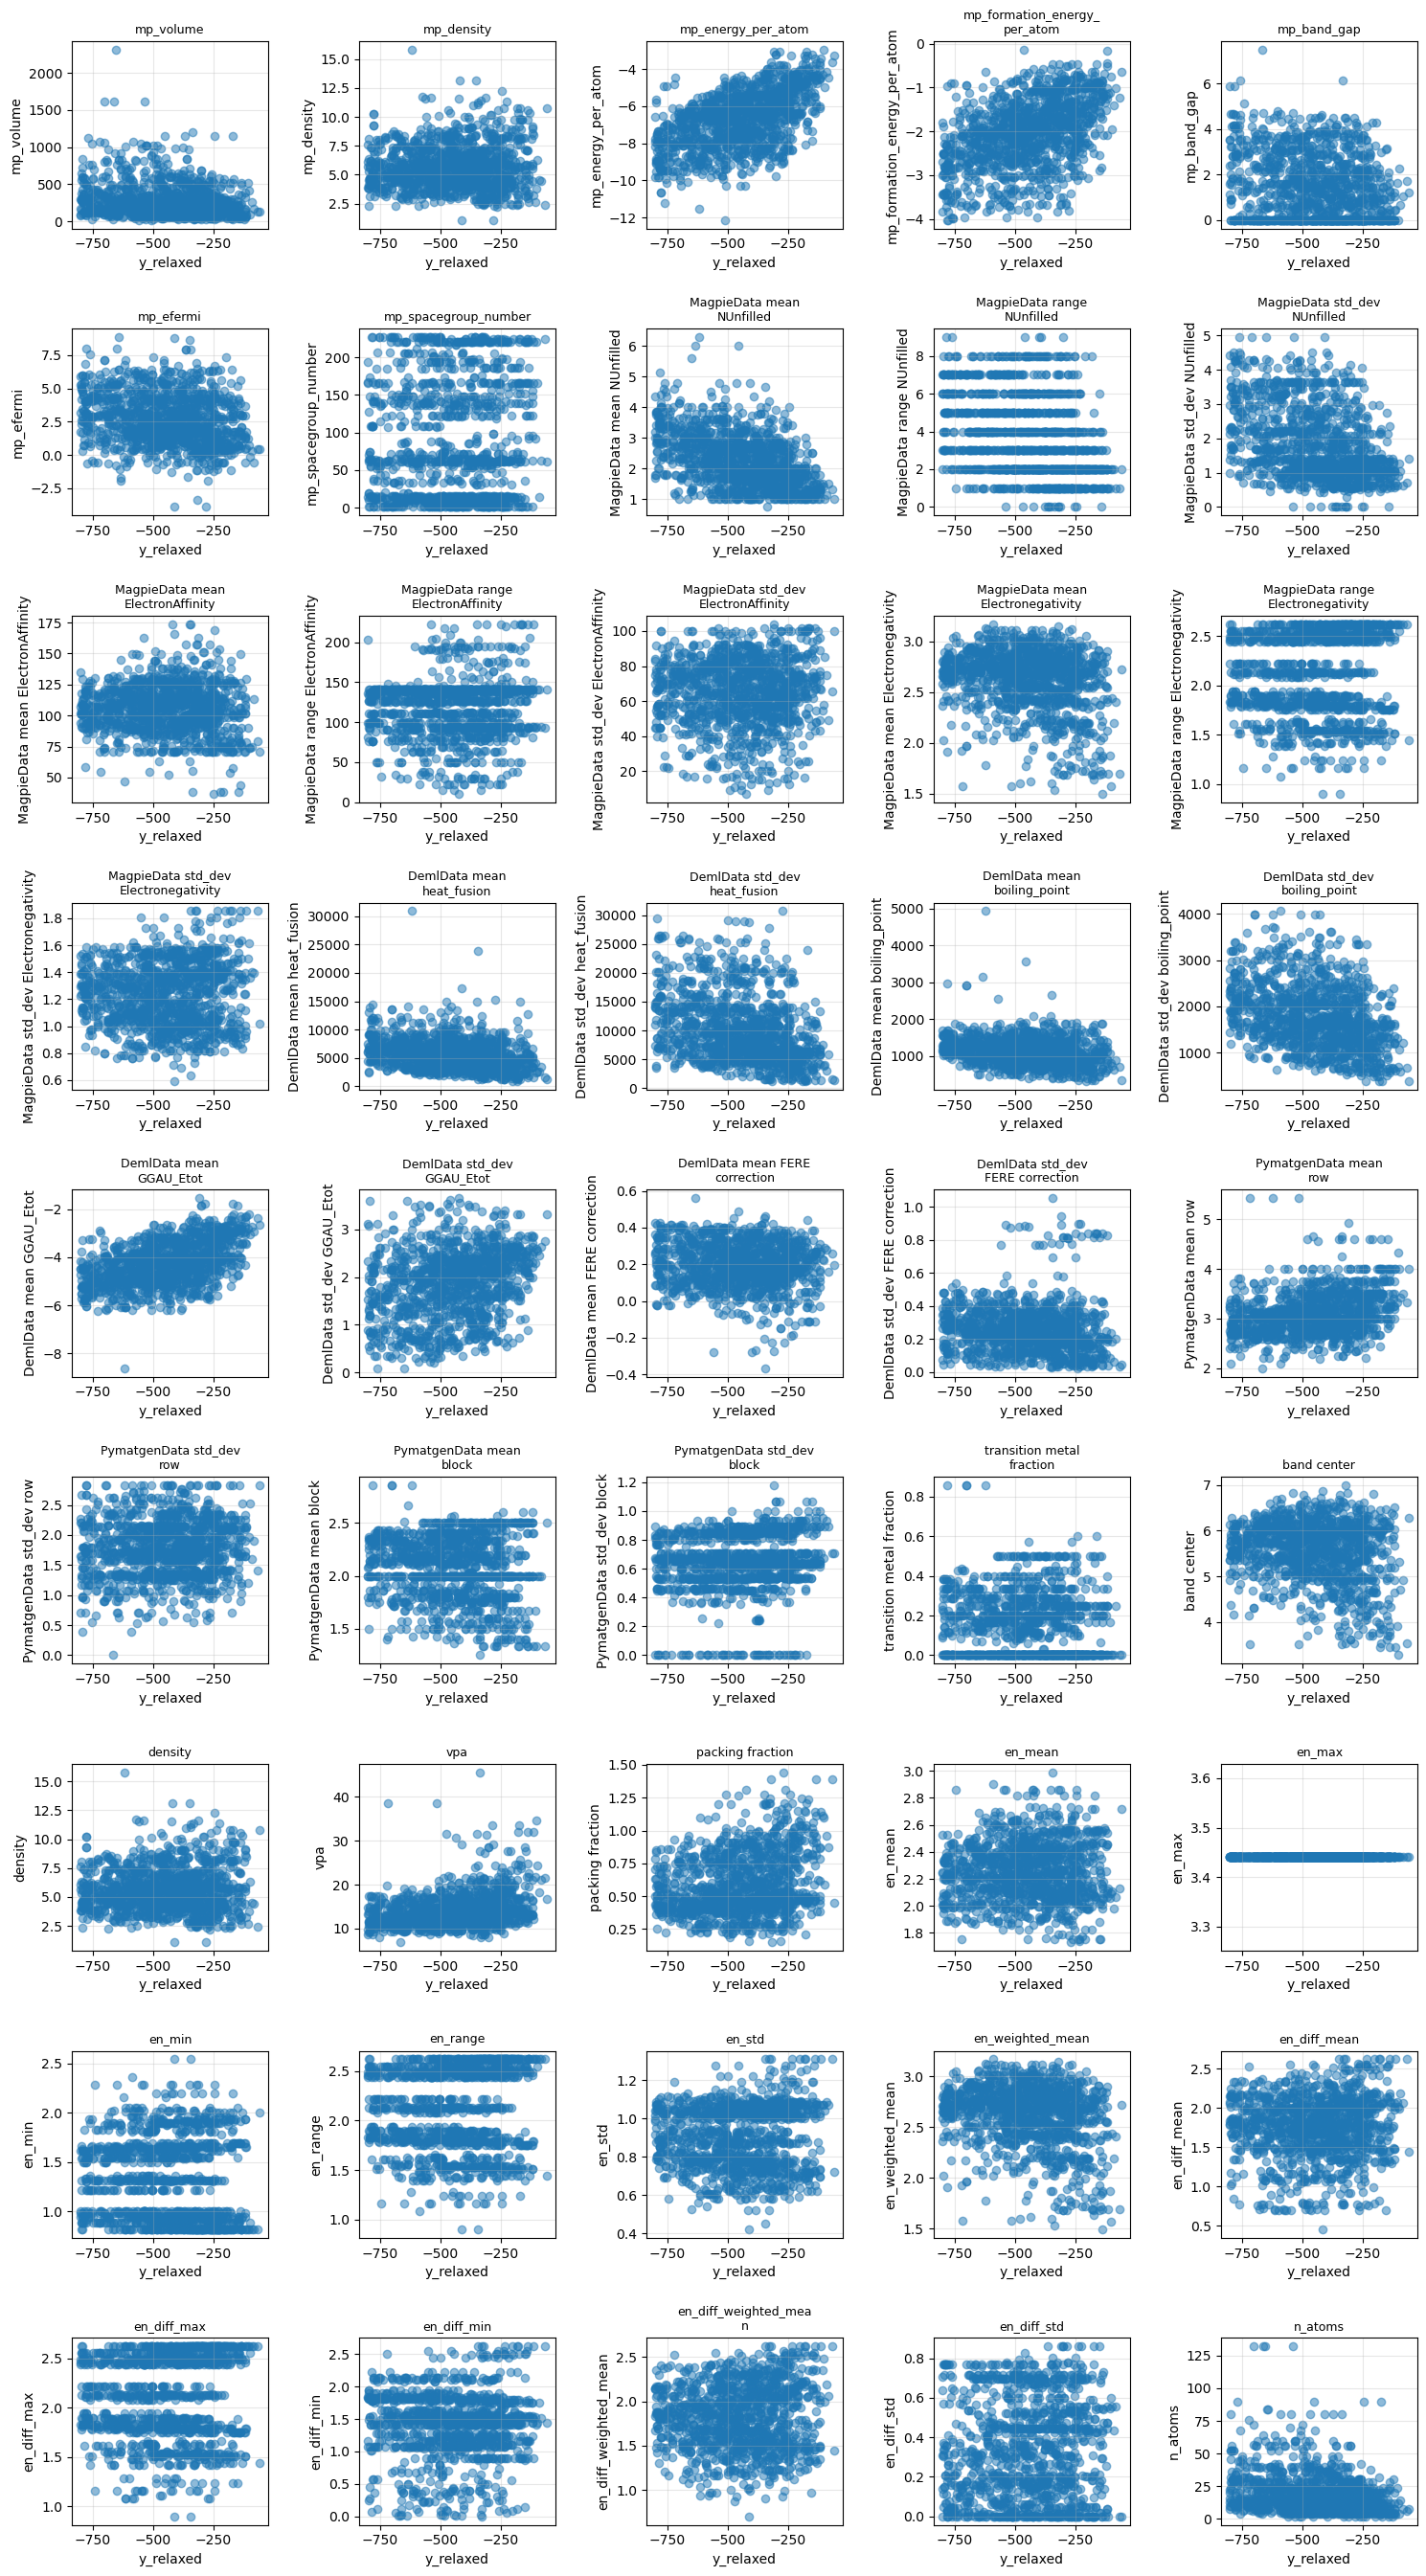

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def plot_features(df, target_col='y_relaxed'):
    """Plot all numeric features against target variable"""
    
    # Get all numeric columns except the target
    feature_cols = [c for c in df.columns if c != target_col]
    
    n_features = len(feature_cols)
    n_cols = 5
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(feature_cols):
        # Filter out NaN values
        mask = df[target_col].notna() & df[col].notna()
        axes[idx].scatter(df.loc[mask, target_col], df.loc[mask, col], alpha=0.5)
        axes[idx].set_xlabel(target_col)
        axes[idx].set_ylabel(col)
        # Wrap long titles
        wrapped_title = '\n'.join(textwrap.wrap(col, width=20))
        axes[idx].set_title(wrapped_title, fontsize=9)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout(h_pad=2.0, w_pad=1.5)
    plt.show()

# Usage
plot_features(h_feat_dropped)

### Save Featurized Dataframe

In [10]:
h_feat_dropped.to_csv("h_feat_dropped.csv", index=False)

### Correlation Analysis

computing corr matrix for 45 features


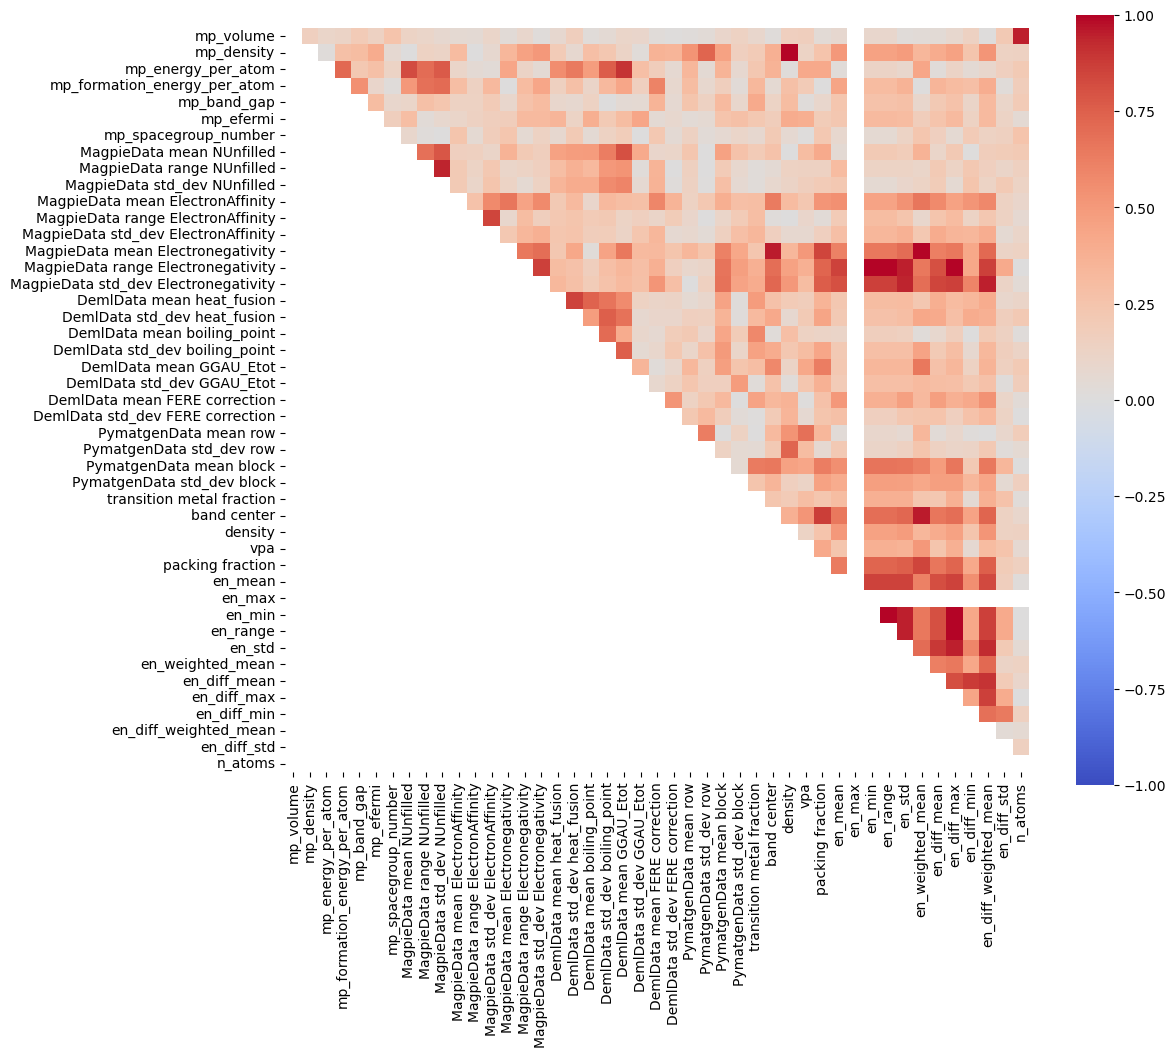

In [11]:
import seaborn as sns

# h_feat_dropped = pd.read_csv("h_feat_dropped.csv")
h_X = h_feat_dropped.drop(columns=['y_relaxed'])
h_y = h_feat_dropped['y_relaxed']

def get_corr_mat(df, show_pairs=False, threshold=0.9):
    print(f"computing corr matrix for {len(df.columns)} features")
    corr_mat = df.corr().abs()
    upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)) 
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(upper_tri, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
    plt.show()

    if show_pairs:
        high_corr_pairs = []
        for column in upper_tri.columns:
            for row in upper_tri.index:
                if abs(upper_tri.loc[row, column]) > threshold:
                    high_corr_pairs.append((row, column, upper_tri.loc[row, column]))

        # Convert the list of pairs to a DataFrame for better readability
        high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])

        # Sort by absolute correlation value for better inspection
        high_corr_df = high_corr_df.sort_values(by="Correlation", key=abs, ascending=False)

        return high_corr_df

get_corr_mat(h_X, show_pairs=False)

In [12]:
# drop high corr features
# h_X = h_X.drop(columns=['density', 'vpa', 'band center', 'frac f valence electrons'])
# h_X = h_X.drop(columns=['dist from 1 clusters |APE| < 0.010', 'dist from 3 clusters |APE| < 0.010', 'dist from 5 clusters |APE| < 0.010'])

### Regression

In [13]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def parity_plot(X, y, model, title):
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    plt.figure(figsize=(6,6), dpi=100)
    plt.scatter(y, y_pred, alpha=0.5, color='#2E86AB')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)

    metrics_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}'
    plt.text(0.05, 0.95, metrics_text, 
             transform=plt.gca().transAxes,
             fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel('Actual y_relaxed (eV)', fontsize=12, fontweight='bold')
    plt.ylabel('Predicted y_relaxed (eV)', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

Ridge Regression
Best params: {'ridge__alpha': 79.06043210907701}
Best CV R²: 0.350
OOF R²: 0.353


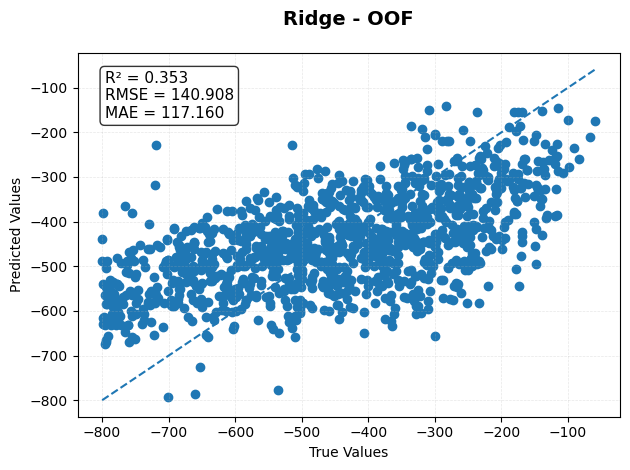


Lasso Regression
Best params: {'lasso__alpha': 0.8395578619995121}
Best CV R²: 0.350
OOF R²: 0.353


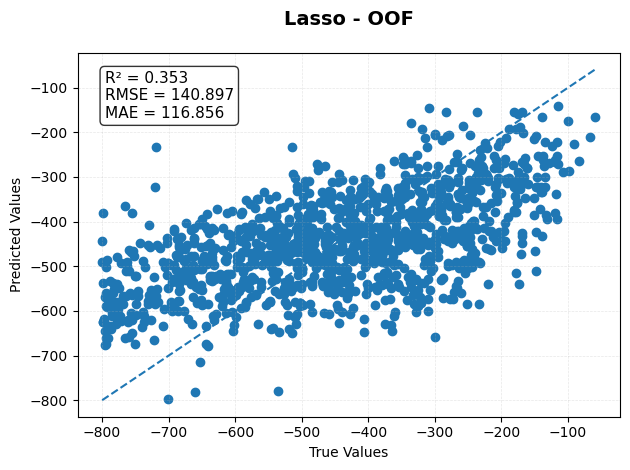


Lasso Feature Selection
Non-zero Coefficients: 28 / 45


In [14]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

def parity_plot_oof(y_true, y_pred, title="Parity Plot"):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], linestyle="--")

    metrics_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}'
    plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

cv = KFold(n_splits=5, shuffle=True, random_state=1065)

# ==========================================
# RIDGE REGRESSION WITH PIPELINE + OOF R2
# ==========================================

ridge_param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(random_state=1065))
])

ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=ridge_param_grid,
    n_iter=50,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    random_state=1065
)

ridge_search.fit(h_X, h_y)

print("="*50)
print("Ridge Regression")
print("="*50)
print("Best params:", ridge_search.best_params_)
print(f"Best CV R²: {ridge_search.best_score_:.3f}")

# ---- Get Out-of-Fold (OOF) predictions ----
ridge_oof_pred = cross_val_predict(
    ridge_search.best_estimator_, h_X, h_y, cv=cv, n_jobs=-1
)

ridge_oof_r2 = r2_score(h_y, ridge_oof_pred)
print(f"OOF R²: {ridge_oof_r2:.3f}")

# Optional parity plot with OOF predictions
parity_plot_oof(h_y, ridge_oof_pred, title="Ridge - OOF")


# ==========================================
# LASSO REGRESSION WITH PIPELINE + OOF R2
# ==========================================

lasso_param_grid = {
    "lasso__alpha": np.logspace(-4, 1, 80)
}

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(random_state=1065, max_iter=2000000, tol=1e-3, selection='random'))
])

lasso_search = RandomizedSearchCV(
    estimator=lasso_pipe,
    param_distributions=lasso_param_grid,
    n_iter=50,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    random_state=1065
)

lasso_search.fit(h_X, h_y)

print("\n" + "="*50)
print("Lasso Regression")
print("="*50)
print("Best params:", lasso_search.best_params_)
print(f"Best CV R²: {lasso_search.best_score_:.3f}")

# ---- Out-of-Fold Predictions ----
lasso_oof_pred = cross_val_predict(
    lasso_search.best_estimator_, h_X, h_y, cv=cv, n_jobs=-1
)

lasso_oof_r2 = r2_score(h_y, lasso_oof_pred)
print(f"OOF R²: {lasso_oof_r2:.3f}")

parity_plot_oof(h_y, lasso_oof_pred, title="Lasso - OOF")


# ==========================================
# LASSO FEATURE SELECTION
# ==========================================

final_lasso = lasso_search.best_estimator_["lasso"]

print("\n" + "="*50)
print("Lasso Feature Selection")
print("="*50)
print(f"Non-zero Coefficients: {np.sum(final_lasso.coef_ != 0)} / {len(final_lasso.coef_)}")


Best CV Score: 0.390
Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 15, 'max_features': 0.7, 'max_depth': 3, 'learning_rate': 0.05}
Out-of-Fold R² Score: 0.392


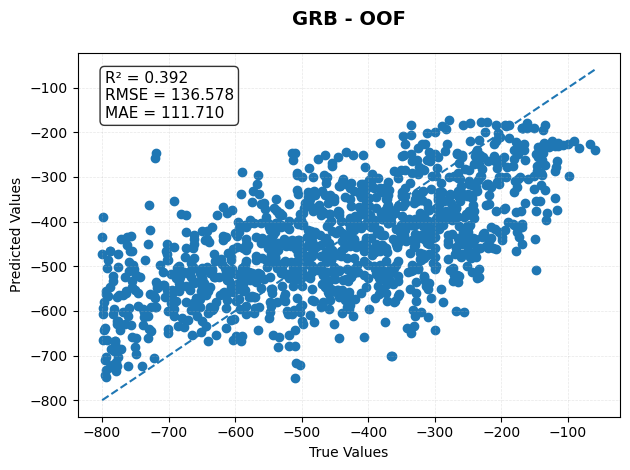


Final model trained on full dataset


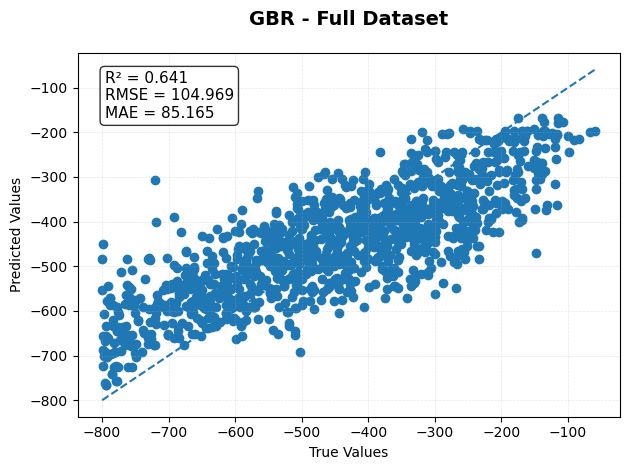

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
import numpy as np

h_gbr = GradientBoostingRegressor(random_state=1065)

param_grid_basic = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [4, 8, 15],
    'subsample': [0.6, 0.7, 0.8],
    'max_features': [0.5, 0.7, 'sqrt'],
}

param_grid_comprehensive = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

def rand_search_cv(X, y, model, param_grid):
    rand_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=100,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        random_state=1065,
    )
    rand_search.fit(X, y)
    return rand_search

# Use all data (no train-test split)
h_cv = rand_search_cv(X=h_X, y=h_y, model=h_gbr, param_grid=param_grid_basic)
h_best_gbr_model = h_cv.best_estimator_

print(f"Best CV Score: {h_cv.best_score_:.3f}")
print(f"Best parameters: {h_cv.best_params_}")

# Get out-of-fold predictions using cross_val_predict
h_oof_predictions = cross_val_predict(
    h_best_gbr_model, 
    h_X, 
    h_y, 
    cv=5, 
    n_jobs=-1
)

# Calculate out-of-fold R² score
from sklearn.metrics import r2_score
oof_r2 = r2_score(h_y, h_oof_predictions)
print(f"Out-of-Fold R² Score: {oof_r2:.3f}")

parity_plot_oof(h_y, h_oof_predictions, "GRB - OOF")

# Optional: Retrain on full dataset for final model
h_best_gbr_model.fit(h_X, h_y)
print("\nFinal model trained on full dataset")

y_pred_full = h_best_gbr_model.predict(h_X)
parity_plot_oof(h_y, y_pred_full, "GBR - Full Dataset")

MODEL COMPARISON (Out-of-Fold) - Initial Screening

Evaluating Gradient Boosting...
  OOF R²: 0.3223 | CV R² (mean): 0.3176 ± 0.0863
  OOF RMSE: 144.2231 | OOF MAE: 111.9130

Evaluating XGBoost...
  OOF R²: 0.3233 | CV R² (mean): 0.3197 ± 0.0675
  OOF RMSE: 144.1265 | OOF MAE: 112.4111

Evaluating LightGBM...
  OOF R²: 0.3500 | CV R² (mean): 0.3466 ± 0.0635
  OOF RMSE: 141.2476 | OOF MAE: 111.4367

Evaluating CatBoost...
  OOF R²: 0.3857 | CV R² (mean): 0.3834 ± 0.0484
  OOF RMSE: 137.3122 | OOF MAE: 111.5579

Evaluating Random Forest...
  OOF R²: 0.3647 | CV R² (mean): 0.3621 ± 0.0546
  OOF RMSE: 139.6420 | OOF MAE: 112.1893

Evaluating Extra Trees...
  OOF R²: 0.3510 | CV R² (mean): 0.3477 ± 0.0627
  OOF RMSE: 141.1398 | OOF MAE: 113.2142

Evaluating Ridge...
  OOF R²: 0.3397 | CV R² (mean): 0.3368 ± 0.0514
  OOF RMSE: 142.3599 | OOF MAE: 117.5151

Evaluating Lasso...
  OOF R²: 0.3407 | CV R² (mean): 0.3377 ± 0.0524
  OOF RMSE: 142.2613 | OOF MAE: 117.4426

Evaluating ElasticNet...
 

/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.472e+06, tolerance: 2.970e+03
  model = cd_fast.enet_coordinate_descent(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.907e+06, tolerance: 2.987e+03
  model = cd_fast.enet_coordinate_descent(
/Us


Best parameters: {'selection': 'cyclic', 'alpha': 1.0}

Best CV R² (from search): 0.3398
OOF R² (cross_val_predict): 0.3429
OOF RMSE: 142.0153
OOF MAE: 117.7098

HYPERPARAMETER TUNING: ElasticNet

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.584e+06, tolerance: 2.919e+03
  model = cd_fast.enet_coordinate_descent(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.197e+06, tolerance: 2.937e+03
  model = cd_fast.enet_coordinate_descent(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre


Best parameters: {'selection': 'random', 'l1_ratio': 0.7, 'alpha': 0.1}

Best CV R² (from search): 0.3400
OOF R² (cross_val_predict): 0.3432
OOF RMSE: 141.9835
OOF MAE: 117.6280

HYPERPARAMETER TUNING: Neural Network

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/hliu/miniconda3/envs/ocp/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.wa


Best parameters: {'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 100), 'alpha': 0.001, 'activation': 'relu'}

Best CV R² (from search): 0.3110
OOF R² (cross_val_predict): 0.3146
OOF RMSE: 145.0448
OOF MAE: 118.2121

STACKED ENSEMBLE MODEL (Out-of-Fold)

Generating out-of-fold predictions for stacked ensemble...

Stacked Ensemble OOF Results:
  OOF R²: 0.3825
  OOF RMSE: 137.6780
  OOF MAE: 112.6521

Training stacked ensemble on full dataset...

TUNED MODELS - OUT-OF-FOLD R² COMPARISON
Model                         OOF R²       RMSE        MAE
--------------------------------------------------------------------------------
Gradient Boosting             0.3957   136.1925   111.4169
XGBoost                       0.3933   136.4658   111.7288
CatBoost                      0.3927   136.5354   111.8856
LightGBM                      0.3881   137.0446   112.4451
Stacked Ensemble              0.3825   137.6780   112.6521
Extra Trees                   0.3795

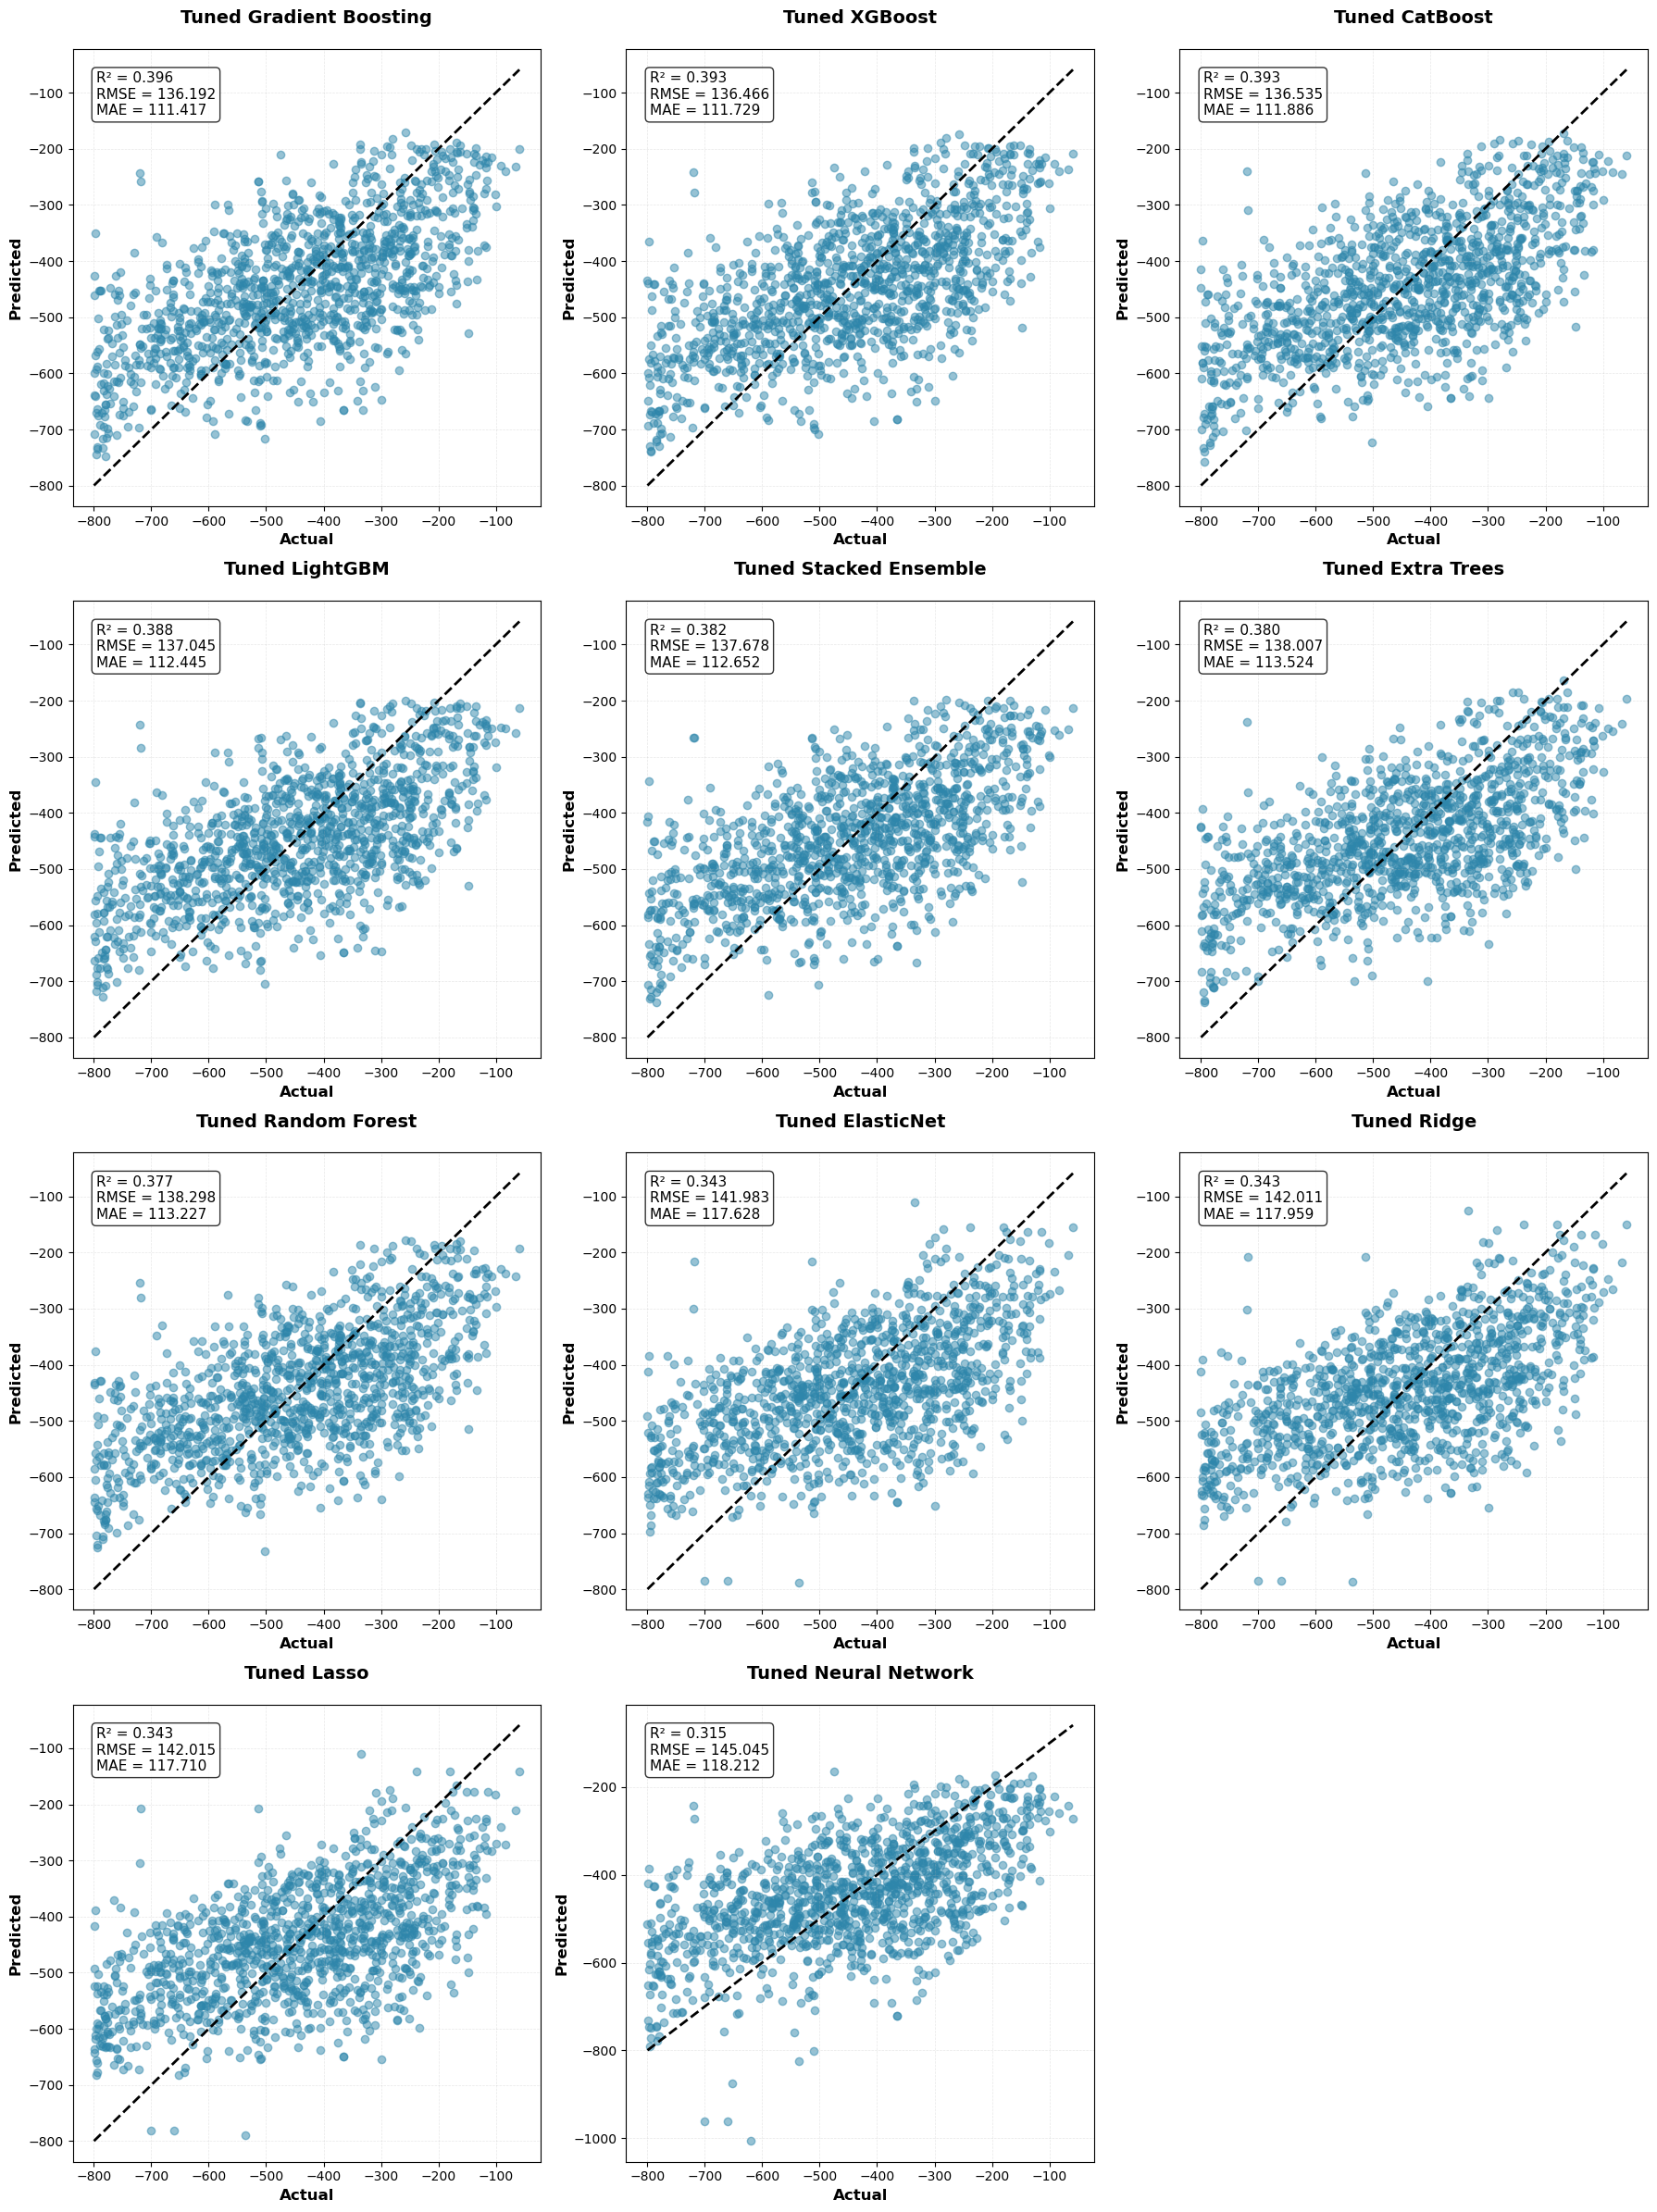


TOP 20 MOST IMPORTANT FEATURES (Gradient Boosting)
                         feature  importance
              mp_energy_per_atom    0.342227
       MagpieData mean NUnfilled    0.053472
                             vpa    0.052382
                       mp_volume    0.046899
    mp_formation_energy_per_atom    0.045525
                         n_atoms    0.041612
                       mp_efermi    0.036749
                     mp_band_gap    0.030067
        PymatgenData std_dev row    0.025266
      DemlData std_dev GGAU_Etot    0.023548
         DemlData mean GGAU_Etot    0.019944
DemlData std_dev FERE correction    0.019739
            mp_spacegroup_number    0.019197
   DemlData mean FERE correction    0.018121
           PymatgenData mean row    0.014736
    DemlData std_dev heat_fusion    0.014665
     DemlData mean boiling_point    0.014468
  DemlData std_dev boiling_point    0.012505
    MagpieData std_dev NUnfilled    0.011948
       DemlData mean heat_fusion    0.011654


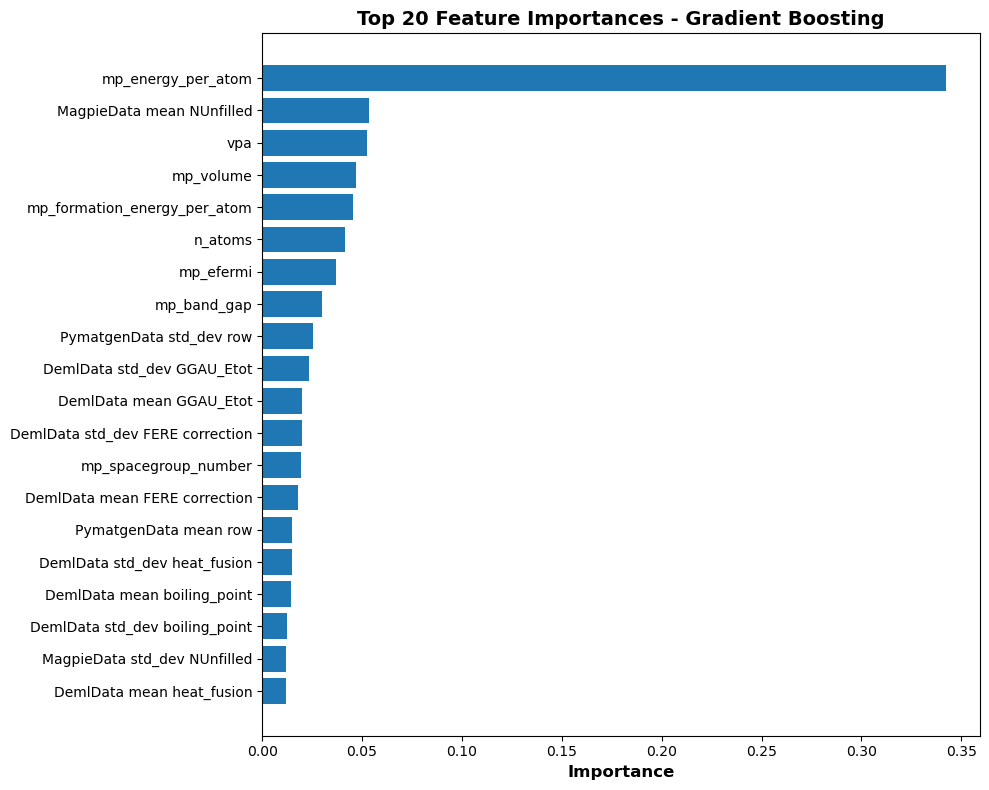


ANALYSIS COMPLETE
All models have been tuned and evaluated using out-of-fold predictions.
All tuned models are now trained on the full dataset and ready for deployment.

Best performing model: Gradient Boosting (OOF R² = 0.3957)

Generated files:
  - all_tuned_models_oof_comparison.png (11 tuned models)
  - feature_importance.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# Gradient Boosting variants
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Linear models
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Neural network
from sklearn.neural_network import MLPRegressor

# Stacking
from sklearn.ensemble import StackingRegressor


def parity_plot(y_true, y_pred, title, ax=None):
    """Create parity plot with metrics"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    ax.scatter(y_true, y_pred, alpha=0.5, color='#2E86AB')
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
            'k--', lw=2, label='Perfect prediction')
    
    metrics_text = f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}'
    ax.text(0.05, 0.95, metrics_text, 
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Actual', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    return r2, rmse, mae


def compare_models_oof(X, y, cv=5, scale_features=False):
    """
    Compare multiple regression models using out-of-fold predictions
    WITHOUT creating parity plots (will be done after tuning)
    """
    
    # Optional feature scaling
    if scale_features:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X
    
    # Define models to test
    models = {
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_samples_leaf=4,
            subsample=0.8,
            random_state=1065
        ),
        'XGBoost': XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=1065,
            tree_method='hist'
        ),
        'LightGBM': LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=1065,
            verbose=-1
        ),
        'CatBoost': CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=5,
            subsample=0.8,
            random_state=1065,
            verbose=False
        ),
        'Random Forest': RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=4,
            random_state=1065,
            n_jobs=-1
        ),
        'Extra Trees': ExtraTreesRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=4,
            random_state=1065,
            n_jobs=-1
        ),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1, max_iter=5000),
        'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
        'Neural Network': MLPRegressor(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            max_iter=1000,
            random_state=1065,
            early_stopping=True
        )
    }
    
    results = []
    
    print("="*80)
    print("MODEL COMPARISON (Out-of-Fold) - Initial Screening")
    print("="*80)
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        # Use scaled or unscaled data
        if name in ['Ridge', 'Lasso', 'ElasticNet', 'Neural Network']:
            X_use = X_scaled
        else:
            X_use = X
        
        # Get out-of-fold predictions
        try:
            oof_pred = cross_val_predict(model, X_use, y, cv=cv, n_jobs=-1)
        except Exception as e:
            print(f"  Error with {name}: {e}")
            continue
        
        # Calculate OOF metrics
        oof_r2 = r2_score(y, oof_pred)
        oof_rmse = np.sqrt(mean_squared_error(y, oof_pred))
        oof_mae = mean_absolute_error(y, oof_pred)
        
        # Get CV scores for comparison
        cv_scores = cross_val_score(model, X_use, y, cv=cv, scoring='r2', n_jobs=-1)
        cv_r2_mean = cv_scores.mean()
        cv_r2_std = cv_scores.std()
        
        results.append({
            'Model': name,
            'OOF R²': oof_r2,
            'CV R² (mean)': cv_r2_mean,
            'CV R² (std)': cv_r2_std,
            'OOF RMSE': oof_rmse,
            'OOF MAE': oof_mae,
        })
        
        print(f"  OOF R²: {oof_r2:.4f} | CV R² (mean): {cv_r2_mean:.4f} ± {cv_r2_std:.4f}")
        print(f"  OOF RMSE: {oof_rmse:.4f} | OOF MAE: {oof_mae:.4f}")
    
    # Sort by OOF R²
    results_sorted = sorted(results, key=lambda x: x['OOF R²'], reverse=True)
    
    # Print summary table
    print("\n" + "="*80)
    print("INITIAL RESULTS SUMMARY (sorted by OOF R²)")
    print("="*80)
    print(f"{'Model':<20} {'OOF R²':>10} {'CV R²':>10} {'CV Std':>10} {'RMSE':>8} {'MAE':>8}")
    print("-"*80)
    for r in results_sorted:
        print(f"{r['Model']:<20} {r['OOF R²']:>10.4f} {r['CV R² (mean)']:>10.4f} "
              f"{r['CV R² (std)']:>10.4f} {r['OOF RMSE']:>8.4f} {r['OOF MAE']:>8.4f}")
    
    return results_sorted


def hyperparameter_tune_model_oof(X, y, model_name, cv=5, scale_features=False):
    """
    Perform hyperparameter tuning using cross-validation and return OOF predictions
    Now supports ALL 10 models
    """
    print(f"\n{'='*80}")
    print(f"HYPERPARAMETER TUNING: {model_name}")
    print(f"{'='*80}\n")
    
    # Optional feature scaling
    if scale_features:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X
    
    # Use scaled data for linear models and neural networks
    if model_name in ['Ridge', 'Lasso', 'ElasticNet', 'Neural Network']:
        X_use = X_scaled
    else:
        X_use = X
    
    # Define model and parameter grid based on model name
    if model_name == 'LightGBM':
        model = LGBMRegressor(random_state=1065, verbose=-1)
        param_grid = {
            'n_estimators': [200, 300, 500, 700],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [4, 5, 6, 7, 8],
            'num_leaves': [20, 31, 40, 50],
            'min_child_samples': [10, 20, 30, 40],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'reg_alpha': [0, 0.01, 0.1, 1.0],
            'reg_lambda': [0, 0.01, 0.1, 1.0]
        }
        n_iter = 100
    
    elif model_name == 'XGBoost':
        model = XGBRegressor(random_state=1065, tree_method='hist')
        param_grid = {
            'n_estimators': [200, 300, 500, 700],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [4, 5, 6, 7, 8],
            'min_child_weight': [1, 3, 5, 7],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'gamma': [0, 0.1, 0.5, 1.0],
            'reg_alpha': [0, 0.01, 0.1, 1.0],
            'reg_lambda': [0, 0.01, 0.1, 1.0]
        }
        n_iter = 100
    
    elif model_name == 'CatBoost':
        model = CatBoostRegressor(random_state=1065, verbose=False)
        param_grid = {
            'iterations': [200, 300, 500, 700],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'depth': [4, 5, 6, 7, 8],
            'l2_leaf_reg': [1, 3, 5, 7, 9],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bylevel': [0.7, 0.8, 0.9, 1.0]
        }
        n_iter = 100
    
    elif model_name == 'Gradient Boosting':
        model = GradientBoostingRegressor(random_state=1065)
        param_grid = {
            'n_estimators': [200, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'max_features': ['sqrt', 'log2', None]
        }
        n_iter = 80
    
    elif model_name == 'Random Forest':
        model = RandomForestRegressor(random_state=1065, n_jobs=-1)
        param_grid = {
            'n_estimators': [200, 300, 500],
            'max_depth': [10, 15, 20, 25, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False]
        }
        n_iter = 80
    
    elif model_name == 'Extra Trees':
        model = ExtraTreesRegressor(random_state=1065, n_jobs=-1)
        param_grid = {
            'n_estimators': [200, 300, 500],
            'max_depth': [10, 15, 20, 25, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False]
        }
        n_iter = 80
    
    elif model_name == 'Ridge':
        model = Ridge()
        param_grid = {
            'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']
        }
        n_iter = 30
    
    elif model_name == 'Lasso':
        model = Lasso(max_iter=5000)
        param_grid = {
            'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
            'selection': ['cyclic', 'random']
        }
        n_iter = 20
    
    elif model_name == 'ElasticNet':
        model = ElasticNet(max_iter=5000)
        param_grid = {
            'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
            'selection': ['cyclic', 'random']
        }
        n_iter = 30
    
    elif model_name == 'Neural Network':
        model = MLPRegressor(random_state=1065, early_stopping=True, max_iter=1000)
        param_grid = {
            'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100), (150, 100, 50)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate': ['constant', 'adaptive'],
            'learning_rate_init': [0.001, 0.01]
        }
        n_iter = 50
    
    else:
        raise ValueError(f"Model {model_name} not supported for tuning")
    
    # Randomized search with cross-validation
    rand_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        random_state=1065,
        verbose=1
    )
    
    rand_search.fit(X_use, y)
    best_model = rand_search.best_estimator_
    
    # Get out-of-fold predictions using the best model
    oof_pred = cross_val_predict(best_model, X_use, y, cv=cv, n_jobs=-1)
    
    # Calculate metrics
    oof_r2 = r2_score(y, oof_pred)
    oof_rmse = np.sqrt(mean_squared_error(y, oof_pred))
    oof_mae = mean_absolute_error(y, oof_pred)
    
    print(f"\nBest parameters: {rand_search.best_params_}")
    print(f"\nBest CV R² (from search): {rand_search.best_score_:.4f}")
    print(f"OOF R² (cross_val_predict): {oof_r2:.4f}")
    print(f"OOF RMSE: {oof_rmse:.4f}")
    print(f"OOF MAE: {oof_mae:.4f}")
    
    return best_model, rand_search.best_params_, oof_pred


def create_stacked_ensemble_oof(X, y, cv=5):
    """
    Create a stacked ensemble and return out-of-fold predictions
    """
    print(f"\n{'='*80}")
    print("STACKED ENSEMBLE MODEL (Out-of-Fold)")
    print(f"{'='*80}\n")
    
    # Base models
    base_models = [
        ('lgbm', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, 
                               subsample=0.8, random_state=1065, verbose=-1)),
        ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                             subsample=0.8, random_state=1065, tree_method='hist')),
        ('catboost', CatBoostRegressor(iterations=300, learning_rate=0.05, depth=5,
                                       random_state=1065, verbose=False)),
        ('rf', RandomForestRegressor(n_estimators=200, max_depth=15, 
                                     random_state=1065, n_jobs=-1))
    ]
    
    # Meta-learner
    meta_model = Ridge(alpha=1.0)
    
    # Create stacking regressor with cross-validation built-in
    stacking_model = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_model,
        cv=cv,
        n_jobs=-1
    )
    
    print("Generating out-of-fold predictions for stacked ensemble...")
    
    # Get out-of-fold predictions
    oof_pred = cross_val_predict(stacking_model, X, y, cv=cv, n_jobs=-1)
    
    # Calculate metrics
    oof_r2 = r2_score(y, oof_pred)
    oof_rmse = np.sqrt(mean_squared_error(y, oof_pred))
    oof_mae = mean_absolute_error(y, oof_pred)
    
    print(f"\nStacked Ensemble OOF Results:")
    print(f"  OOF R²: {oof_r2:.4f}")
    print(f"  OOF RMSE: {oof_rmse:.4f}")
    print(f"  OOF MAE: {oof_mae:.4f}")
    
    # Fit on full dataset for final model
    print("\nTraining stacked ensemble on full dataset...")
    stacking_model.fit(X, y)
    
    return stacking_model, oof_pred


# ==================== MAIN EXECUTION ====================

# 1. Compare all models using out-of-fold predictions (initial screening, NO plots)
results = compare_models_oof(h_X, h_y, cv=5, scale_features=True)

# 2. Tune ALL 10 models
print(f"\n{'='*80}")
print(f"TUNING ALL MODELS")
print(f"{'='*80}")

tuned_results = []

# List of all models to tune
all_models = [
    'LightGBM', 'XGBoost', 'CatBoost', 'Gradient Boosting',
    'Random Forest', 'Extra Trees', 'Ridge', 'Lasso', 
    'ElasticNet', 'Neural Network'
]

for model_name in all_models:
    try:
        tuned_model, best_params, tuned_oof_pred = hyperparameter_tune_model_oof(
            h_X, h_y, 
            model_name=model_name,
            cv=5,
            scale_features=True
        )
        
        tuned_results.append({
            'model_name': model_name,
            'tuned_model': tuned_model,
            'best_params': best_params,
            'oof_predictions': tuned_oof_pred,
            'oof_r2': r2_score(h_y, tuned_oof_pred),
            'oof_rmse': np.sqrt(mean_squared_error(h_y, tuned_oof_pred)),
            'oof_mae': mean_absolute_error(h_y, tuned_oof_pred)
        })
    except Exception as e:
        print(f"\nError tuning {model_name}: {e}")
        continue

# 3. Try stacked ensemble with out-of-fold predictions
stacked_model, stacked_oof_pred = create_stacked_ensemble_oof(h_X, h_y, cv=5)

# Add stacked ensemble to tuned results
tuned_results.append({
    'model_name': 'Stacked Ensemble',
    'tuned_model': stacked_model,
    'best_params': None,
    'oof_predictions': stacked_oof_pred,
    'oof_r2': r2_score(h_y, stacked_oof_pred),
    'oof_rmse': np.sqrt(mean_squared_error(h_y, stacked_oof_pred)),
    'oof_mae': mean_absolute_error(h_y, stacked_oof_pred)
})

# Sort tuned results by OOF R²
tuned_results_sorted = sorted(tuned_results, key=lambda x: x['oof_r2'], reverse=True)

# 4. Print summary of ALL tuned models
print("\n" + "="*80)
print("TUNED MODELS - OUT-OF-FOLD R² COMPARISON")
print("="*80)
print(f"{'Model':<25} {'OOF R²':>10} {'RMSE':>10} {'MAE':>10}")
print("-"*80)
for result in tuned_results_sorted:
    print(f"{result['model_name']:<25} {result['oof_r2']:>10.4f} "
          f"{result['oof_rmse']:>10.4f} {result['oof_mae']:>10.4f}")

# 5. Create parity plots for ALL TUNED MODELS (including stacked ensemble)
n_tuned = len(tuned_results_sorted)
n_cols = 3
n_rows = int(np.ceil(n_tuned / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_tuned > 1 else [axes]

print("\n" + "="*80)
print("CREATING PARITY PLOTS FOR ALL TUNED MODELS")
print("="*80)

for idx, result in enumerate(tuned_results_sorted):
    parity_plot(h_y, result['oof_predictions'], 
               f"Tuned {result['model_name']}", axes[idx])

# Hide any unused subplots
for idx in range(n_tuned, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('all_tuned_models_oof_comparison.png', dpi=150, bbox_inches='tight')
print(f"Saved parity plots to 'all_tuned_models_oof_comparison.png'")
plt.show()

# 6. Feature importance from best tuned model
best_tuned_model = tuned_results_sorted[0]['tuned_model']

if hasattr(best_tuned_model, 'feature_importances_'):
    import pandas as pd
    
    feature_importance = pd.DataFrame({
        'feature': h_X.columns,
        'importance': best_tuned_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n" + "="*80)
    print(f"TOP 20 MOST IMPORTANT FEATURES ({tuned_results_sorted[0]['model_name']})")
    print("="*80)
    print(feature_importance.head(20).to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance.head(20)['feature'], 
             feature_importance.head(20)['importance'])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f"Top 20 Feature Importances - {tuned_results_sorted[0]['model_name']}", 
             fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("All models have been tuned and evaluated using out-of-fold predictions.")
print("All tuned models are now trained on the full dataset and ready for deployment.")
print(f"\nBest performing model: {tuned_results_sorted[0]['model_name']} "
      f"(OOF R² = {tuned_results_sorted[0]['oof_r2']:.4f})")
print("\nGenerated files:")
print(f"  - all_tuned_models_oof_comparison.png ({len(tuned_results_sorted)} tuned models)")
print("  - feature_importance.png")